https://www.uclahealth.org/news/article/4-surprising-health-effects-noise-pollution

Searching through the data.gov, came across two data sets reported by the city of san francisco. One dataset having to do with aircraft noise exceedances as reported by SFO. The other having to do with emergency calls

evaluation of the impact of noise pollution on (emergencies / health). There is (known?) association of noise pollution on health. We cannot randomly assign / directly prescribe noise pollution. We can pseudo assign randomness by evaluating emergency calls based on noise pollution? (refer to INFO 251 example of random air pollution)

https://data.sfgov.org/Public-Safety/Fire-Department-and-Emergency-Medical-Services-Dis/nuek-vuh3/explore/query/SELECT%0A%20%20%60call_number%60%2C%0A%20%20%60unit_id%60%2C%0A%20%20%60incident_number%60%2C%0A%20%20%60call_type%60%2C%0A%20%20%60call_date%60%2C%0A%20%20%60received_dttm%60%2C%0A%20%20%60entry_dttm%60%2C%0A%20%20%60dispatch_dttm%60%2C%0A%20%20%60response_dttm%60%2C%0A%20%20%60on_scene_dttm%60%2C%0A%20%20%60transport_dttm%60%2C%0A%20%20%60hospital_dttm%60%2C%0A%20%20%60call_final_disposition%60%2C%0A%20%20%60available_dttm%60%2C%0A%20%20%60address%60%2C%0A%20%20%60city%60%2C%0A%20%20%60zipcode_of_incident%60%2C%0A%20%20%60battalion%60%2C%0A%20%20%60station_area%60%2C%0A%20%20%60original_priority%60%2C%0A%20%20%60priority%60%2C%0A%20%20%60final_priority%60%2C%0A%20%20%60als_unit%60%2C%0A%20%20%60call_type_group%60%2C%0A%20%20%60number_of_alarms%60%2C%0A%20%20%60unit_type%60%2C%0A%20%20%60unit_sequence_in_call_dispatch%60%2C%0A%20%20%60fire_prevention_district%60%2C%0A%20%20%60supervisor_district%60%2C%0A%20%20%60neighborhoods_analysis_boundaries%60%2C%0A%20%20%60rowid%60%2C%0A%20%20%60case_location%60%0AWHERE%0A%20%20%60data_as_of%60%0A%20%20%20%20BETWEEN%20%222025-01-01T00%3A40%3A38%22%20%3A%3A%20floating_timestamp%0A%20%20%20%20AND%20%222026-01-01T00%3A40%3A38%22%20%3A%3A%20floating_timestamp/page/filter


https://data.sfgov.org/Transportation/Aircraft-Noise-Exceedances/tiju-qyvs/about_data

https://data.sfgov.org/Transportation/Aircraft-Noise-Climates/qxw2-ncq3/data_preview

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, date


In [21]:
locations = pd.read_csv("location_ids.csv")
locations = locations[['location_id', 'location', 'longitude', 'latitude', 'elevation']].drop_duplicates()

In [22]:
type(locations)

pandas.DataFrame

In [23]:
noise = pd.read_csv("Aircraft_Noise_Exceedances.csv")
noise.head()

,location_id,corr_id,max_date_time,classification,sel,max_level,duration,day_night,operation_no,flight_date_time,operation_type,runway_name,aircraft_type,aircraft_category,airline_code,airline,other_port,airport_code,data_as_of,data_loaded_at
0,12,20089481,2023/03/19 11:50:49 PM,1,80.1,71.1,19,Night,40362643.0,2023-03-19 23:54:37,A,28R,A321,J,JBU,JETBLUE AIRWAYS,BOS,SFO,2024/04/25 02:51:44 PM,2026/03/10 06:26:28 AM
1,23,20089470,2023/03/20 12:01:27 AM,1,83.7,74.8,24,Night,40362637.0,2023-03-19 23:58:54,D,01L,B738,J,AMX,AEROMEXICO,MEX,SFO,2024/04/25 02:51:44 PM,2026/03/10 06:26:28 AM
2,12,20089477,2023/03/20 12:33:18 AM,1,82.9,72.4,24,Night,40362641.0,2023-03-20 00:38:38,A,28R,B737,J,SWA,SOUTHWEST AIRLINES,DEN,SFO,2024/04/25 02:51:44 PM,2026/03/10 06:26:28 AM
3,12,20107287,2023/04/04 12:09:11 AM,1,81.5,70.3,28,Night,40421725.0,2023-04-04 00:14:27,A,28R,B739,J,DAL,DELTA AIR LINES,MSP,SFO,2024/04/25 02:51:44 PM,2026/03/10 06:26:28 AM
4,5,20107288,2023/04/04 01:29:52 AM,1,92.4,83.4,30,Night,40421844.0,2023-04-04 01:28:30,D,28L,B77W,J,CAL,CHINA AIRLINES,TPE,SFO,2024/04/25 02:51:44 PM,2026/03/10 06:26:28 AM


### Add the location information to the noise df

In [24]:
noise_locations = noise.merge(locations, on='location_id', how='left')

In [26]:
noise_locations.head()


,location_id,corr_id,max_date_time,classification,sel,max_level,duration,day_night,operation_no,flight_date_time,...,airline_code,airline,other_port,airport_code,data_as_of,data_loaded_at,location,longitude,latitude,elevation
0,12,20089481,2023/03/19 11:50:49 PM,1,80.1,71.1,19,Night,40362643.0,2023-03-19 23:54:37,...,JBU,JETBLUE AIRWAYS,BOS,SFO,2024/04/25 02:51:44 PM,2026/03/10 06:26:28 AM,Foster City,-122.253,37.565,1.0
1,23,20089470,2023/03/20 12:01:27 AM,1,83.7,74.8,24,Night,40362637.0,2023-03-19 23:58:54,...,AMX,AEROMEXICO,MEX,SFO,2024/04/25 02:51:44 PM,2026/03/10 06:26:28 AM,San Francisco,-122.399,37.711,20.0
2,12,20089477,2023/03/20 12:33:18 AM,1,82.9,72.4,24,Night,40362641.0,2023-03-20 00:38:38,...,SWA,SOUTHWEST AIRLINES,DEN,SFO,2024/04/25 02:51:44 PM,2026/03/10 06:26:28 AM,Foster City,-122.253,37.565,1.0
3,12,20107287,2023/04/04 12:09:11 AM,1,81.5,70.3,28,Night,40421725.0,2023-04-04 00:14:27,...,DAL,DELTA AIR LINES,MSP,SFO,2024/04/25 02:51:44 PM,2026/03/10 06:26:28 AM,Foster City,-122.253,37.565,1.0
4,5,20107288,2023/04/04 01:29:52 AM,1,92.4,83.4,30,Night,40421844.0,2023-04-04 01:28:30,...,CAL,CHINA AIRLINES,TPE,SFO,2024/04/25 02:51:44 PM,2026/03/10 06:26:28 AM,San Bruno,-122.413,37.628,25.0


In [27]:
noise_locations['clean_max_date_time'] = pd.to_datetime(noise_locations['max_date_time'], format="%Y/%m/%d %I:%M:%S %p")

In [28]:
noise_locations.head()

,location_id,corr_id,max_date_time,classification,sel,max_level,duration,day_night,operation_no,flight_date_time,...,airline,other_port,airport_code,data_as_of,data_loaded_at,location,longitude,latitude,elevation,clean_max_date_time
0,12,20089481,2023/03/19 11:50:49 PM,1,80.1,71.1,19,Night,40362643.0,2023-03-19 23:54:37,...,JETBLUE AIRWAYS,BOS,SFO,2024/04/25 02:51:44 PM,2026/03/10 06:26:28 AM,Foster City,-122.253,37.565,1.0,2023-03-19 23:50:49
1,23,20089470,2023/03/20 12:01:27 AM,1,83.7,74.8,24,Night,40362637.0,2023-03-19 23:58:54,...,AEROMEXICO,MEX,SFO,2024/04/25 02:51:44 PM,2026/03/10 06:26:28 AM,San Francisco,-122.399,37.711,20.0,2023-03-20 00:01:27
2,12,20089477,2023/03/20 12:33:18 AM,1,82.9,72.4,24,Night,40362641.0,2023-03-20 00:38:38,...,SOUTHWEST AIRLINES,DEN,SFO,2024/04/25 02:51:44 PM,2026/03/10 06:26:28 AM,Foster City,-122.253,37.565,1.0,2023-03-20 00:33:18
3,12,20107287,2023/04/04 12:09:11 AM,1,81.5,70.3,28,Night,40421725.0,2023-04-04 00:14:27,...,DELTA AIR LINES,MSP,SFO,2024/04/25 02:51:44 PM,2026/03/10 06:26:28 AM,Foster City,-122.253,37.565,1.0,2023-04-04 00:09:11
4,5,20107288,2023/04/04 01:29:52 AM,1,92.4,83.4,30,Night,40421844.0,2023-04-04 01:28:30,...,CHINA AIRLINES,TPE,SFO,2024/04/25 02:51:44 PM,2026/03/10 06:26:28 AM,San Bruno,-122.413,37.628,25.0,2023-04-04 01:29:52


In [40]:
sf_noise = noise_locations[noise_locations['location'] == 'San Francisco']

In [43]:
sf_noise['location_id'].value_counts()

location_id
23    11561
24     5129
21      919
25      700
27      300
26      167
Name: count, dtype: int64

In [55]:
# Convert to datetime if it's currently a string
sf_noise['max_date_time'] = pd.to_datetime(sf_noise['max_date_time'])


/var/folders/1r/_gd8nm2931d2rl2rndmd2_0m0000gn/T/ipykernel_1046/3312255547.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sf_noise['max_date_time'] = pd.to_datetime(sf_noise['max_date_time'])


In [57]:
sf_noise['max_date'] = sf_noise['max_date_time'].dt.date
sf_noise['max_time'] = sf_noise['max_date_time'].dt.time


In [109]:
sf_noise['year'] = sf_noise['max_date_time'].dt.year

In [110]:
sf_noise.head()

,location_id,corr_id,max_date_time,classification,sel,max_level,duration,day_night,operation_no,flight_date_time,...,data_as_of,data_loaded_at,location,longitude,latitude,elevation,clean_max_date_time,max_date,max_time,year
1,23,20089470,2023-03-20 00:01:27,1,83.7,74.8,24,Night,40362637.0,2023-03-19 23:58:54,...,2024/04/25 02:51:44 PM,2026/03/10 06:26:28 AM,San Francisco,-122.399,37.711,20.0,2023-03-20 00:01:27,2023-03-20,00:01:27,2023
10,23,20092575,2023-03-22 22:08:35,1,80.8,70.3,20,Night,40371860.0,2023-03-22 22:05:54,...,2024/04/25 02:51:44 PM,2026/03/10 06:26:28 AM,San Francisco,-122.399,37.711,20.0,2023-03-22 22:08:35,2023-03-22,22:08:35,2023
14,23,20093807,2023-03-24 00:22:14,1,79.8,70.2,21,Night,40376115.0,2023-03-24 00:19:04,...,2024/04/25 02:51:44 PM,2026/03/10 06:26:28 AM,San Francisco,-122.399,37.711,20.0,2023-03-24 00:22:14,2023-03-24,00:22:14,2023
40,24,20091672,2023-03-22 00:58:29,6,79.1,73.9,34,Night,40368750.0,2023-03-22 01:08:21,...,2024/04/25 02:51:44 PM,2026/03/10 06:26:28 AM,San Francisco,-122.411,37.726,165.0,2023-03-22 00:58:29,2023-03-22,00:58:29,2023
43,23,20093701,2023-03-23 22:05:53,1,82.7,72.5,25,Night,40375913.0,2023-03-23 22:03:09,...,2024/04/25 02:51:44 PM,2026/03/10 06:26:28 AM,San Francisco,-122.399,37.711,20.0,2023-03-23 22:05:53,2023-03-23,22:05:53,2023


In [103]:
one_day = sf_noise[sf_noise['max_date'] == date(2024, 12, 31)]
len(one_day)

87

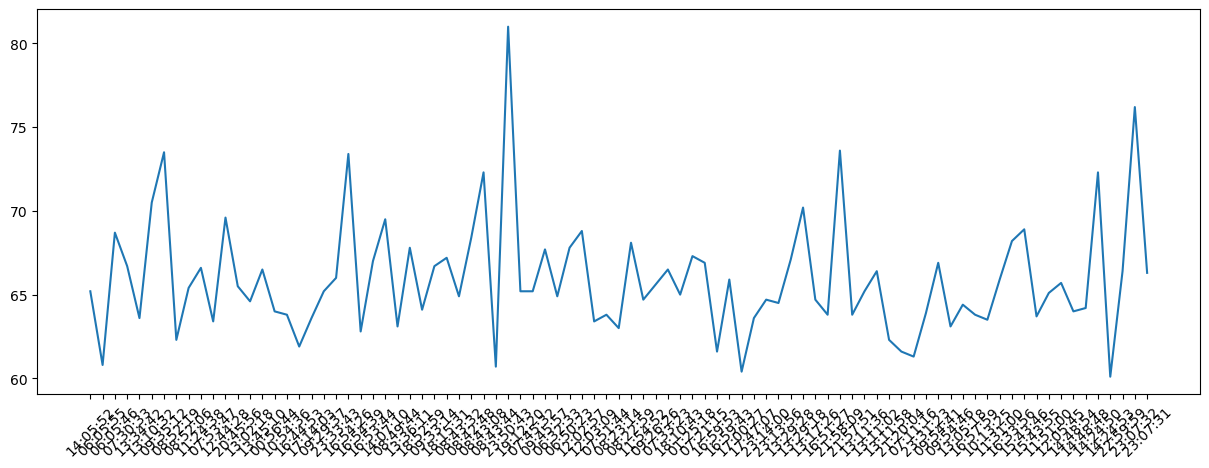

In [108]:
one_day['max_time'] = one_day['max_time'].astype(str)

plt.figure(figsize=(15, 5))
plt.plot(one_day['max_time'], one_day['max_level'])
plt.xticks(rotation=45)
plt.show()

## Maybe evaluate based on dates or even date ranges where there are a ton of flights

In [112]:
year_2023 = sf_noise[sf_noise['year']==2023]
len(year_2023)

1874

## Histogram; frequency of max_level occurences

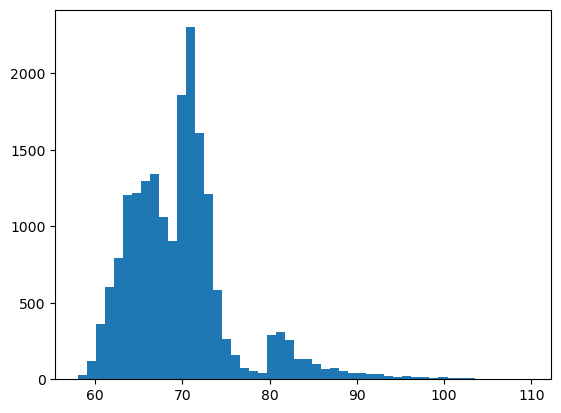

In [47]:
plt.hist(sf_noise['max_level'], bins=50)
plt.show()

https://data.sfgov.org/Transportation/Aircraft-Noise-Exceedances/tiju-qyvs/about_data

In [29]:
emergency = pd.read_csv("Fire_Department_and_Emergency_Medical_Services_Dispatched_Calls_for_Service_20260315.csv")

In [30]:
emergency.head()

,Call Number,Unit ID,Incident Number,Call Type,Call Date,Received DtTm,Entry DtTm,Dispatch DtTm,Response DtTm,On Scene DtTm,...,ALS Unit,Call Type Group,Number of Alarms,Unit Type,Unit sequence in call dispatch,Fire Prevention District,Supervisor District,Neighborhooods - Analysis Boundaries,RowID,case_location
0,243661857,AM215,24183023,Medical Incident,12/31/2024,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,...,False,Non Life-threatening,1,BLS,1.0,3.0,5.0,Tenderloin,243661857-AM215,POINT (-122.411015164 37.78418755)
1,243660122,E36,24182744,Other,12/31/2024,2024 Dec 31 01:36:29 AM,2024 Dec 31 01:36:29 AM,2024 Dec 31 01:36:58 AM,2024 Dec 31 01:39:59 AM,2024 Dec 31 01:40:54 AM,...,True,Alarm,1,ENGINE,1.0,2.0,5.0,Hayes Valley,243660122-E36,POINT (-122.42105326 37.775695233)
2,243660122,B02,24182744,Other,12/31/2024,2024 Dec 31 01:36:29 AM,2024 Dec 31 01:36:29 AM,2024 Dec 31 01:36:58 AM,2024 Dec 31 01:39:02 AM,2024 Dec 31 01:41:31 AM,...,False,Alarm,1,CHIEF,2.0,2.0,5.0,Hayes Valley,243660122-B02,POINT (-122.42105326 37.775695233)
3,243660212,E05,24182765,Medical Incident,12/31/2024,2024 Dec 31 03:17:09 AM,2024 Dec 31 03:18:29 AM,2024 Dec 31 03:18:36 AM,2024 Dec 31 03:20:52 AM,2024 Dec 31 03:22:55 AM,...,True,Potentially Life-Threatening,1,ENGINE,1.0,4.0,5.0,Japantown,243660212-E05,POINT (-122.434729992 37.784944006)
4,243660148,M576,24182750,Medical Incident,12/31/2024,2024 Dec 31 02:06:51 AM,2024 Dec 31 02:09:38 AM,2024 Dec 31 02:10:26 AM,2024 Dec 31 02:10:33 AM,2024 Dec 31 02:23:11 AM,...,True,Potentially Life-Threatening,1,MEDIC,2.0,10.0,10.0,Bayview Hunters Point,243660148-M576,POINT (-122.367922359 37.727398351)


In [33]:
emergency['Call Type'].value_counts()

Call Type
Medical Incident                                241317
Alarms                                           57593
Structure Fire / Smoke in Building               19085
Other                                            12334
Traffic Collision                                11697
Citizen Assist / Service Call                     8030
Outside Fire                                      6832
Gas Leak (Natural and LP Gases)                   3005
Water Rescue                                      2410
Electrical Hazard                                 1938
Elevator / Escalator Rescue                       1428
Vehicle Fire                                       969
Smoke Investigation (Outside)                      783
Odor (Strange / Unknown)                           309
Fuel Spill                                         206
Train / Rail Incident                              182
Administrative                                     178
High Angle Rescue                                   94


In [34]:
emergency['clean_received_dtTm'] = pd.to_datetime(emergency['Received DtTm'], format="%Y %b %d %I:%M:%S %p")

In [35]:
emergency.head()

,Call Number,Unit ID,Incident Number,Call Type,Call Date,Received DtTm,Entry DtTm,Dispatch DtTm,Response DtTm,On Scene DtTm,...,Call Type Group,Number of Alarms,Unit Type,Unit sequence in call dispatch,Fire Prevention District,Supervisor District,Neighborhooods - Analysis Boundaries,RowID,case_location,clean_received_dtTm
0,243661857,AM215,24183023,Medical Incident,12/31/2024,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,2024 Dec 31 03:19:19 PM,...,Non Life-threatening,1,BLS,1.0,3.0,5.0,Tenderloin,243661857-AM215,POINT (-122.411015164 37.78418755),2024-12-31 15:19:19
1,243660122,E36,24182744,Other,12/31/2024,2024 Dec 31 01:36:29 AM,2024 Dec 31 01:36:29 AM,2024 Dec 31 01:36:58 AM,2024 Dec 31 01:39:59 AM,2024 Dec 31 01:40:54 AM,...,Alarm,1,ENGINE,1.0,2.0,5.0,Hayes Valley,243660122-E36,POINT (-122.42105326 37.775695233),2024-12-31 01:36:29
2,243660122,B02,24182744,Other,12/31/2024,2024 Dec 31 01:36:29 AM,2024 Dec 31 01:36:29 AM,2024 Dec 31 01:36:58 AM,2024 Dec 31 01:39:02 AM,2024 Dec 31 01:41:31 AM,...,Alarm,1,CHIEF,2.0,2.0,5.0,Hayes Valley,243660122-B02,POINT (-122.42105326 37.775695233),2024-12-31 01:36:29
3,243660212,E05,24182765,Medical Incident,12/31/2024,2024 Dec 31 03:17:09 AM,2024 Dec 31 03:18:29 AM,2024 Dec 31 03:18:36 AM,2024 Dec 31 03:20:52 AM,2024 Dec 31 03:22:55 AM,...,Potentially Life-Threatening,1,ENGINE,1.0,4.0,5.0,Japantown,243660212-E05,POINT (-122.434729992 37.784944006),2024-12-31 03:17:09
4,243660148,M576,24182750,Medical Incident,12/31/2024,2024 Dec 31 02:06:51 AM,2024 Dec 31 02:09:38 AM,2024 Dec 31 02:10:26 AM,2024 Dec 31 02:10:33 AM,2024 Dec 31 02:23:11 AM,...,Potentially Life-Threatening,1,MEDIC,2.0,10.0,10.0,Bayview Hunters Point,243660148-M576,POINT (-122.367922359 37.727398351),2024-12-31 02:06:51


In [36]:
med_inc = emergency[emergency['Call Type']=='Medical Incident']

In [39]:
med_inc.columns

Index(['Call Number', 'Unit ID', 'Incident Number', 'Call Type', 'Call Date',
       'Received DtTm', 'Entry DtTm', 'Dispatch DtTm', 'Response DtTm',
       'On Scene DtTm', 'Transport DtTm', 'Hospital DtTm',
       'Call Final Disposition', 'Available DtTm', 'Address', 'City',
       'Zipcode of Incident', 'Battalion', 'Station Area', 'Original Priority',
       'Priority', 'Final Priority', 'ALS Unit', 'Call Type Group',
       'Number of Alarms', 'Unit Type', 'Unit sequence in call dispatch',
       'Fire Prevention District', 'Supervisor District',
       'Neighborhooods - Analysis Boundaries', 'RowID', 'case_location',
       'clean_received_dtTm'],
      dtype='str')